# ScanVI label transfer

In [1]:
from pathlib import Path
import os
import scanpy as sc
from scipy.sparse import issparse
import scvi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import anndata as ad
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


In [3]:
base_dir = Path('/home/workspace/projects/drg')

adata_dir = base_dir / "data/h5ad/export_03/02_neuron-labels"
ref_data_dir = '/home/workspace/private/projects/kim/drg/data/scrna-seq/h5ad/04_clustered'


output_dir = base_dir / "data/h5ad/export_03/03_neuron-scanvi"
scanvi_dir = base_dir / 'scanvi' # csv output
scvi_dir = base_dir / 'scvi/neuron_scanvi'

scanvi_dir.mkdir(parents=True, exist_ok=True)
#ref_data_dir.mkdir(parents= True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

In [4]:
adata = sc.read_h5ad(os.path.join(adata_dir, 'neuron-pca.h5ad'))
refdata = sc.read_h5ad(os.path.join(ref_data_dir, 'GSE139088-scvi-leiden.h5ad'))

### Prepare adatas

In [5]:
print(refdata.layers)
print(adata.layers)

Layers with keys: counts, log1p, normalized_1e6
Layers with keys: counts, log1p, normalized_1e6, nuclear, raw


In [6]:
# restore raw counts, assign same name as query adata
#refdata.layers['counts'] = refdata.layers['raw'].copy()  # Store raw counts
#refdata.X = refdata.layers['counts'].copy()  # Set X to use raw counts

In [7]:
adata.X = adata.layers['counts'].copy()

In [8]:
adata.X[:5, :5].toarray()  # Convert and preview first 5x5 matrix elements

array([[ 0.,  2.,  0.,  0.,  0.],
       [ 3., 20.,  1., 32.,  1.],
       [ 1.,  1.,  1.,  8.,  0.],
       [ 0.,  1.,  0.,  0.,  0.],
       [ 0.,  4.,  0.,  2.,  0.]], dtype=float32)

In [9]:
print(refdata.X[:5, :5])

[[0. 4. 0. 0. 2.]
 [2. 2. 1. 1. 2.]
 [0. 2. 1. 0. 0.]
 [3. 1. 0. 0. 2.]
 [2. 3. 0. 0. 4.]]


In [10]:
# add output_id for refdata
#refdata.obs['output_id'] = refdata.obs['batch']
#refdata.obs.output_id.value_counts()

In [11]:
# add column up here for filtering later only on refdata
refdata.obs['ref_data'] = 'Yes'
adata.obs['ref_data'] = 'No'

## Gene alignment and concatenation

In [12]:
# Find the intersection of genes for integration
common_genes = list(set(adata.var_names) & set(refdata.var_names))
len(common_genes)

208

### Create subsets

In [13]:
# Create copies of the datasets, keeping only common genes
adata_subset = adata[:, common_genes].copy()
refdata_subset = refdata[:, common_genes].copy()

In [14]:
print(f"adata before subsetting: {adata.shape[1]}")
print(f"adata after subsetting: {adata_subset.shape[1]}")

print(f"refdata before subsetting: {refdata.shape[1]}")
print(f"refdata after subsetting: {refdata_subset.shape[1]}")

adata before subsetting: 212
adata after subsetting: 208
refdata before subsetting: 20924
refdata after subsetting: 208


In [15]:
index_match = (adata_subset.var_names == refdata_subset.var_names).all()
print(f"adata.var_names match: {index_match}")

adata.var_names match: True


# Concatenate

In [16]:
print(adata_subset.obs.columns)
print(refdata_subset.obs.columns)

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id',
       'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'log1p_total_counts', 'pct_counts_in_top_10_genes',
       'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores',
       'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels',
       'scvi_model', 'leiden_scVI_1', 'cell_class', 'neuron_recluster',
       'ref_data'],
      dtype='object')
Index(['original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id',
       'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt',
       'pct_counts_mt', 'total_counts_ribosomal', 

In [17]:
# Concatenate datasets
adata_list = [adata_subset, refdata_subset]

adata_concat = ad.concat(adata_list, 
                  join="outer", # make sure it's outer
                  label = 'scanvi_batch',
                  index_unique="-")

In [18]:
adata_concat # confirm number genes

AnnData object with n_obs × n_vars = 47905 × 208
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class', 'neuron_recluster', 'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden', 'scanvi_batch'
    obsm: 'X_pca', 'X_scVI_ModelB_whole_noTG', 'X_umap', '

In [19]:
adata_concat.obs.output_id.value_counts()

output_id
TMA00305    12329
TMA00306    12122
TMA00304     8376
TMA00303     4349
Name: count, dtype: int64

### Perform filtering on concatenated adata

In [20]:
sc.pp.calculate_qc_metrics(adata_concat, percent_top=(10, 20, 50, 150), inplace=True) # adds total_counts metric for filtering

In [21]:
print(f"Empty cell check (min, max): {adata_concat.X.sum(axis=1).min()}, {adata_concat.X.sum(axis=1).max()}")

Empty cell check (min, max): 2.0, 4903.0


In [22]:
# or operator ensures that rows satisfying at least one condition are kept
# so if adata.obs.ref_data = No (study samples), then the cell is kept
# OR if adata.obs.ref_data = Yes AND the cell has acceptable total counts the row is also kept

adata_concat = adata_concat[
    (adata_concat.obs["ref_data"] == "No") |  # Keep all non-reference samples
    ((adata_concat.obs["ref_data"] == "Yes") &  # Apply total_counts filter only to reference samples
     (adata_concat.obs["total_counts"] > 20) & 
     (adata_concat.obs["total_counts"] < 800))
].copy()

In [23]:
print(f"Empty cell check (min, max): {adata_concat.X.sum(axis=1).min()}, {adata_concat.X.sum(axis=1).max()}")

Empty cell check (min, max): 2.0, 4903.0


# Examine Batch Effects

In [24]:
adata_concat.X[:5, :5].toarray()

array([[0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 7., 2., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [25]:
# Normalize and run PCA
sc.pp.normalize_total(adata_concat)
sc.pp.log1p(adata_concat)
sc.pp.pca(adata_concat)

# UMAP colored by output_id
sc.pp.neighbors(adata_concat)
sc.tl.umap(adata_concat)

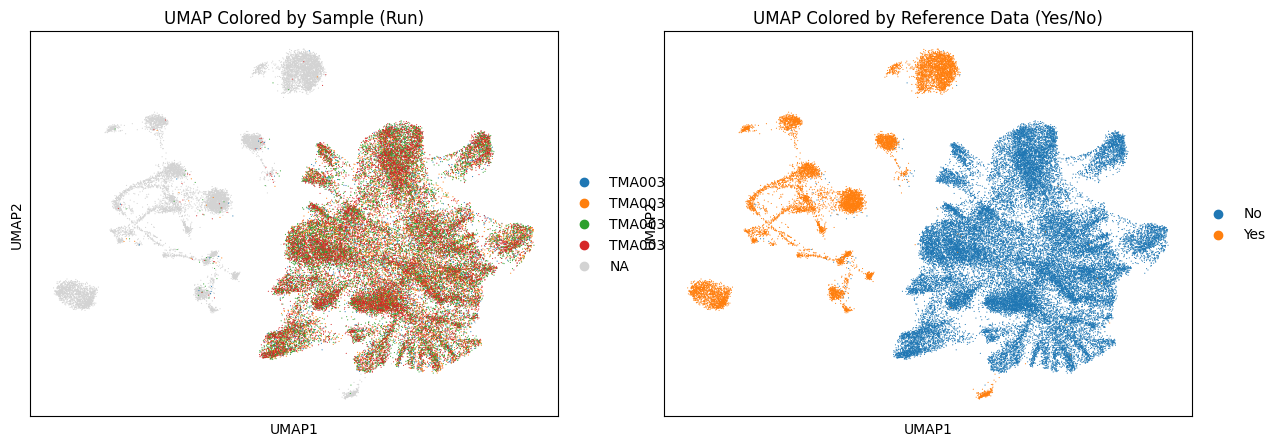

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot UMAP by output_id
sc.pl.umap(adata_concat, color="output_id", show=False, ax=axes[0])
axes[0].set_title("UMAP Colored by Sample (Run)")

# Plot UMAP by ref_data
sc.pl.umap(adata_concat, color="ref_data", show=False, ax=axes[1])
axes[1].set_title("UMAP Colored by Reference Data (Yes/No)")

plt.show()
plt.close()

## Train scVI model

In [27]:
adata_concat

AnnData object with n_obs × n_vars = 47845 × 208
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class', 'neuron_recluster', 'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden', 'scanvi_batch'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_c

In [28]:
# Check batch key
adata_concat.obs["ref_data"] = adata_concat.obs["ref_data"].astype("category")
adata_concat.obs["output_id"] = pd.Categorical(adata_concat.obs["output_id"])
adata_concat.obs['output_id'].value_counts()

output_id
TMA00305    12329
TMA00306    12122
TMA00304     8376
TMA00303     4349
Name: count, dtype: int64

In [29]:
scvi.model.SCVI.setup_anndata(
    adata_concat, 
    layer="counts", # use raw count data
    batch_key='ref_data', # biggest batch effect is panel
)

model = scvi.model.SCVI(adata_concat,
                       n_layers = 2,
                       n_latent = 30)
print('starting model training')

model.train(early_stopping=True, 
            enable_progress_bar=True,
            accelerator = 'gpu'
           )

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


starting model training


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 167/167: 100%|██████████| 167/167 [09:50<00:00,  3.47s/it, v_num=1, train_loss_step=186, train_loss_epoch=194]

`Trainer.fit` stopped: `max_epochs=167` reached.


Epoch 167/167: 100%|██████████| 167/167 [09:50<00:00,  3.54s/it, v_num=1, train_loss_step=186, train_loss_epoch=194]


In [30]:
model.save(os.path.join(scvi_dir, '02_model') , prefix='02_label_transfer_')

In [31]:
SCVI_LATENT_KEY = "X_scVI_refalign"
adata_concat.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

### Compute neighbors graph and UMAP

In [32]:
# neighbors
sc.pp.neighbors(adata_concat, use_rep="X_scVI_refalign", key_added='neighbors_scvi_refalign')
sc.tl.umap(adata_concat, neighbors_key='neighbors_scvi_refalign')

### Export refaligned adata

In [33]:
# save umap dims to csv
umap_df = pd.DataFrame(adata_concat.obsm['X_umap'], index=adata_concat.obs_names, columns=['umap1', 'umap2'])
filename = os.path.join(scanvi_dir, 'adata_scvi_refalign_umap_coords.csv')
umap_df.to_csv(filename)

In [34]:
filename = os.path.join(output_dir, 'adata_concat_scvi_refalign.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

adata_concat.write_h5ad(filename, compression='gzip')

# Checkpoint

In [35]:
filename = os.path.join(output_dir, 'adata_concat_scvi_refalign.h5ad')
adata_concat = sc.read_h5ad(filename)
adata_concat

AnnData object with n_obs × n_vars = 47845 × 208
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class', 'neuron_recluster', 'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden', 'scanvi_batch'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_c

### Prep data for scANVI

In [36]:
adata_concat.obs.columns

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id',
       'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'log1p_total_counts', 'pct_counts_in_top_10_genes',
       'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores',
       'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels',
       'scvi_model', 'leiden_scVI_1', 'cell_class', 'neuron_recluster',
       'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number',
       'sample_id', 'experiment_id', 'total_counts_mt', 'pct_counts_mt',
       'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden',
       'scanvi_batch'],
      dty

In [38]:
# Add 'Unknown' category for original samples if missing, then fill NaN
if 'Unknown' not in adata_concat.obs['original_annotation'].cat.categories:
    adata_concat.obs['original_annotation'] = adata_concat.obs['original_annotation'].cat.add_categories('Unknown')

adata_concat.obs = adata_concat.obs.fillna(value={'original_annotation': 'Unknown'})

In [39]:
adata_concat.obs['original_annotation'].value_counts() # confirm that original_annotation is the most granular

original_annotation
Unknown                       37257
Nonpeptidergic nociceptors     2669
CGRP-Alpha                     1440
C-LTMR                         1414
CGRP-Epsilion                   843
Sst                             757
CGRP-Theta                      723
CGRP-Gamma                      693
TrpM8                           485
CGRP-Zeta                       311
Abeta-RA-LTMR                   261
CGRP-Eta                        253
Proprioceptors                  227
Abeta-Field                     226
Adelta-LTMR                     152
CGRP-Beta                       134
Name: count, dtype: int64

Below is important for mapping labels in the unintegrated original adata

In [40]:
# Subset only query dataset (unlabeled before scANVI training)
query_cells = adata_concat.obs["original_annotation"] == "Unknown"
query_cells.to_csv(os.path.join(scanvi_dir, 'query_cells-subtype.csv'))
query_cells

aaagciof-1-0-0                      True
aaailodo-1-0-0                      True
aaanacfp-1-0-0                      True
aaaohjeo-1-0-0                      True
aabfmjal-1-0-0                      True
                                   ...  
GSM4130750_CCACTACAGATGCCAG-6-1    False
GSM4130750_CCAGCGAAGCTAGCCC-6-1    False
GSM4130750_CCAGCGAAGTGGAGTC-6-1    False
GSM4130750_CCAGCGACAAGAGTCG-6-1    False
GSM4130750_CCAGCGACACATCTTT-6-1    False
Name: original_annotation, Length: 47845, dtype: bool

In [41]:
# fix barcodes; suffix was added during concat
query_cells_copy = query_cells.copy()
query_cells_copy.index = query_cells_copy.index.map(lambda x: x[:-2])
query_cells_copy

aaagciof-1-0                      True
aaailodo-1-0                      True
aaanacfp-1-0                      True
aaaohjeo-1-0                      True
aabfmjal-1-0                      True
                                 ...  
GSM4130750_CCACTACAGATGCCAG-6    False
GSM4130750_CCAGCGAAGCTAGCCC-6    False
GSM4130750_CCAGCGAAGTGGAGTC-6    False
GSM4130750_CCAGCGACAAGAGTCG-6    False
GSM4130750_CCAGCGACACATCTTT-6    False
Name: original_annotation, Length: 47845, dtype: bool

## Run scANVI

In [42]:
# scanvi label transfer
scanvi_model = scvi.model.SCANVI.from_scvi_model(model, 
                                                 adata = adata_concat, 
                                                 unlabeled_category = 'Unknown', # Entries in labels_key to label
                                                 labels_key = 'original_annotation') # Column to transfer labels from

scanvi_model.train(max_epochs=20, 
                   accelerator = 'gpu',
                   n_samples_per_label = None) # this is longer training because it's not subsampling

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Training for 20 epochs.                                                                                   


/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightni

Epoch 20/20: 100%|██████████| 20/20 [02:51<00:00,  8.50s/it, v_num=1, train_loss_step=187, train_loss_epoch=178]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [02:51<00:00,  8.57s/it, v_num=1, train_loss_step=187, train_loss_epoch=178]


In [43]:
# save scANVI model
scanvi_model.save(os.path.join(scvi_dir, '03_model_scanvi') , prefix='03_scanvi_')

### Reference mapping step

In [44]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "scanvi_labels"

adata_concat.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata_concat)
adata_concat.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata_concat) # this fills out the labels

In [45]:
adata_concat.obs['scanvi_labels'].value_counts()

scanvi_labels
Nonpeptidergic nociceptors    8744
CGRP-Alpha                    6747
CGRP-Gamma                    6708
C-LTMR                        3726
CGRP-Eta                      2768
CGRP-Zeta                     2732
Abeta-RA-LTMR                 2563
TrpM8                         2522
Sst                           2154
CGRP-Theta                    1987
CGRP-Epsilion                 1922
Abeta-Field                   1751
Proprioceptors                1635
Adelta-LTMR                   1573
CGRP-Beta                      313
Name: count, dtype: int64

In [46]:
filename = os.path.join(output_dir, 'adata_concat-scvi-scanvi-predictions.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

adata_concat.write_h5ad(filename, compression='gzip')

## Map query labels onto original adata

In [47]:
# re-read fresh adata with all the genes, this is the query
adata_query = sc.read_h5ad(os.path.join(adata_dir, 'neuron-pca.h5ad'))
adata_query.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,doublet_scores,predicted_doublets,batch,slide,_scvi_batch,_scvi_labels,scvi_model,leiden_scVI_1,cell_class,neuron_recluster
aaagciof-1-0,aaagciof-1,634.049133,299.172485,347,0,0,0,0,0,347.0,...,0.053711,False,0,1,0,0,ModelB_whole_noTG,16,Neuron,3
aaailodo-1-0,aaailodo-1,609.569763,308.822144,2415,0,0,0,0,0,2415.0,...,0.056738,False,0,1,0,0,ModelB_whole_noTG,9,Neuron,4
aaanacfp-1-0,aaanacfp-1,634.638367,309.968719,1937,0,0,0,0,0,1937.0,...,0.061728,False,0,1,0,0,ModelB_whole_noTG,16,Neuron,3
aaaohjeo-1-0,aaaohjeo-1,627.379822,297.124298,479,0,0,0,0,0,479.0,...,0.041356,False,0,1,0,0,ModelB_whole_noTG,16,Neuron,0
aabfmjal-1-0,aabfmjal-1,621.577148,367.691040,402,0,0,0,0,0,402.0,...,0.030748,False,0,1,0,0,ModelB_whole_noTG,9,Neuron,4


In [48]:
# create adata_labeled from adata_concat which has the labels
adata_labeled = adata_concat[adata_concat.obs['scanvi_batch'] == '0'].copy() # batch is stored as string

print(adata_labeled.obs['scanvi_batch'].value_counts())
print('')
print(adata_labeled.obs['output_id'].value_counts())

scanvi_batch
0    37176
Name: count, dtype: int64

output_id
TMA00305    12329
TMA00306    12122
TMA00304     8376
TMA00303     4349
Name: count, dtype: int64


In [49]:
# Remove suffix from labeled adata subset from adata_concat
adata_labeled.obs.index = adata_labeled.obs.index.astype(str)
adata_labeled.obs.index = adata_labeled.obs.index.str[:-2]
adata_labeled.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,sample_number,sample_id,experiment_id,total_counts_mt,pct_counts_mt,total_counts_ribosomal,pct_counts_ribosomal,leiden,scanvi_batch,scanvi_labels
aaagciof-1-0,aaagciof-1,634.049133,299.172485,347.0,0.0,0.0,0.0,0.0,0.0,178.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Adelta-LTMR
aaailodo-1-0,aaailodo-1,609.569763,308.822144,2415.0,0.0,0.0,0.0,0.0,0.0,1879.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,CGRP-Eta
aaanacfp-1-0,aaanacfp-1,634.638367,309.968719,1937.0,0.0,0.0,0.0,0.0,0.0,1454.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Adelta-LTMR
aaaohjeo-1-0,aaaohjeo-1,627.379822,297.124298,479.0,0.0,0.0,0.0,0.0,0.0,199.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Adelta-LTMR
aabfmjal-1-0,aabfmjal-1,621.577148,367.691040,402.0,0.0,0.0,0.0,0.0,0.0,297.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,CGRP-Gamma


In [50]:
# fix barcodes; suffix was added during concat
#query_cells_copy = query_cells.copy()
#query_cells_copy.index = query_cells_copy.index.map(lambda x: x[:-2])

In [51]:
#  Clean up query_cells_copy
## check it's a list of valid cell IDs that exist in both AnnData objects

if isinstance(query_cells_copy, pd.Series) and query_cells_copy.dtype == bool:
    query_cells_copy = query_cells_copy[query_cells_copy].index.tolist()

# Restrict to intersection of cell IDs in both datasets
query_cells_copy = [c for c in query_cells_copy if c in adata_labeled.obs_names and c in adata_query.obs_names]

print(f"{len(query_cells_copy)} overlapping cells between labeled and query datasets.")

37176 overlapping cells between labeled and query datasets.


In [52]:
# Transfer predictions back to the original query dataset
adata_query.obs.loc[query_cells_copy, 'scanvi_labels'] = adata_labeled.obs.loc[query_cells_copy, "scanvi_labels"]
adata_query.obs['scanvi_labels']

aaagciof-1-0                   Adelta-LTMR
aaailodo-1-0                      CGRP-Eta
aaanacfp-1-0                   Adelta-LTMR
aaaohjeo-1-0                   Adelta-LTMR
aabfmjal-1-0                    CGRP-Gamma
                           ...            
ojabjopo-1-3                    CGRP-Alpha
ojbjiocj-1-3                 Abeta-RA-LTMR
ojbnljfj-1-3                    CGRP-Alpha
ojbojfpi-1-3                    CGRP-Alpha
ojcapmap-1-3    Nonpeptidergic nociceptors
Name: scanvi_labels, Length: 37176, dtype: category
Categories (15, object): ['Abeta-Field', 'Abeta-RA-LTMR', 'Adelta-LTMR', 'C-LTMR', ..., 'Nonpeptidergic nociceptors', 'Proprioceptors', 'Sst', 'TrpM8']

In [53]:
adata_query.obs.scanvi_labels.value_counts()

scanvi_labels
Nonpeptidergic nociceptors    6051
CGRP-Gamma                    6008
CGRP-Alpha                    5304
CGRP-Eta                      2514
CGRP-Zeta                     2420
Abeta-RA-LTMR                 2303
C-LTMR                        2302
TrpM8                         2036
Abeta-Field                   1525
Adelta-LTMR                   1418
Proprioceptors                1408
Sst                           1385
CGRP-Theta                    1247
CGRP-Epsilion                 1073
CGRP-Beta                      182
Name: count, dtype: int64

## Export labeled adata

In [54]:
h5ad_path = os.path.join(output_dir, 'neuron-scanvi-labels.h5ad')
adata_query.write_h5ad(h5ad_path, compression='gzip')

print(h5ad_path)

/home/workspace/projects/drg/data/h5ad/export_03/03_neuron-scanvi/neuron-scanvi-labels.h5ad


## Session info

In [55]:
print('active IDE: sc-spatial-gpu')
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment:  sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
